Task 2: Quantitative analysis using pynance and TaLib

Prepare my Data

In [2]:
import pandas as pd

df = pd.read_csv("../data/AMZN.csv")

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.718,2.7265,2.5535,2.5675,145928000
1,2009-01-05,2.703,2.7870,2.6515,2.7865,190196000
2,2009-01-06,2.868,2.9110,2.6875,2.7275,221602000
3,2009-01-07,2.810,2.8475,2.7675,2.8145,158854000
4,2009-01-08,2.858,2.8660,2.7290,2.7495,131558000


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.info()
df.isnull().sum()
df = df.dropna()

<class 'pandas.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3774 non-null   float64
 1   High    3774 non-null   float64
 2   Low     3774 non-null   float64
 3   Open    3774 non-null   float64
 4   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB


Compute SMA

In [4]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()

df['SMA_50'] = df['Close'].rolling(window=50).mean()

Compute EMA

In [5]:
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

Compute RSI

In [6]:
import ta

df['RSI'] = ta.momentum.RSIIndicator(df['Close']).rsi()

Compute MACD

In [7]:
macd = ta.trend.MACD(df['Close'])

df['MACD'] = macd.macd()

df['MACD_signal'] = macd.macd_signal()

Price + Moving Average Plot

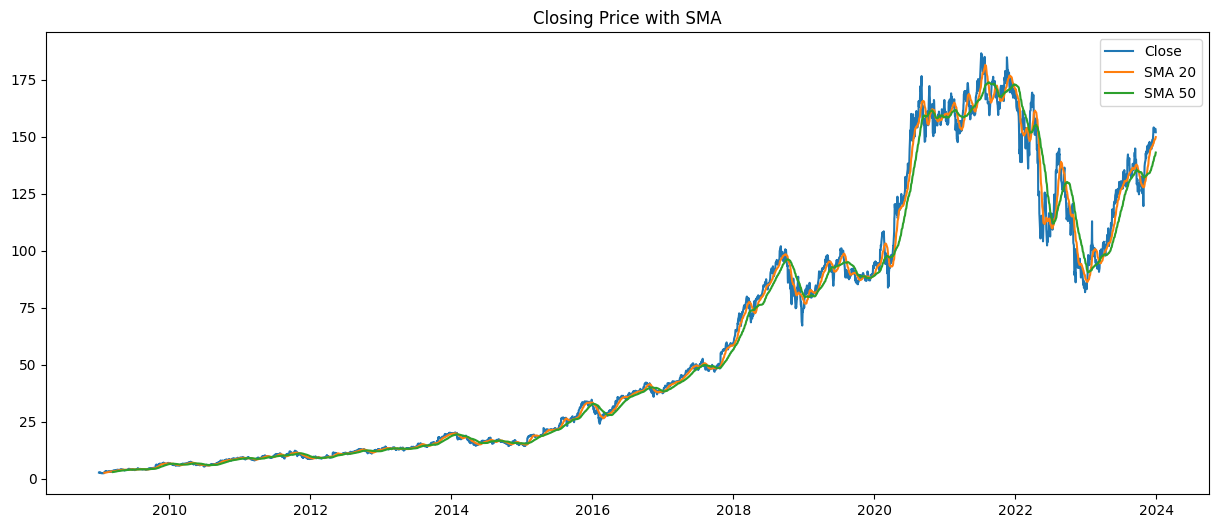

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(df['Close'], label='Close')

plt.plot(df['SMA_20'], label='SMA 20')

plt.plot(df['SMA_50'], label='SMA 50')

plt.legend()

plt.title("Closing Price with SMA")

plt.show()

RSI Plot

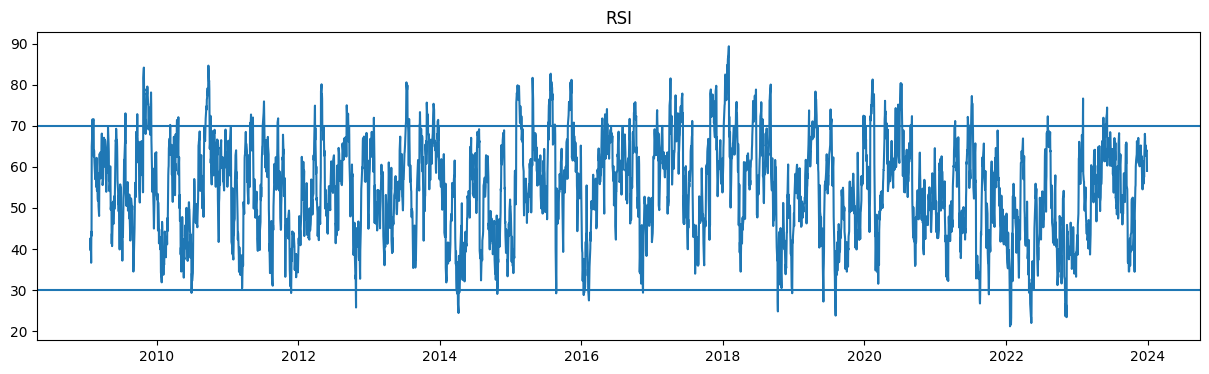

In [9]:
plt.figure(figsize=(15,4))

plt.plot(df['RSI'])

plt.axhline(70)

plt.axhline(30)

plt.title("RSI")

plt.show()

RSI > 70 → stoke overbought
RSI < 30 → stoke oversold

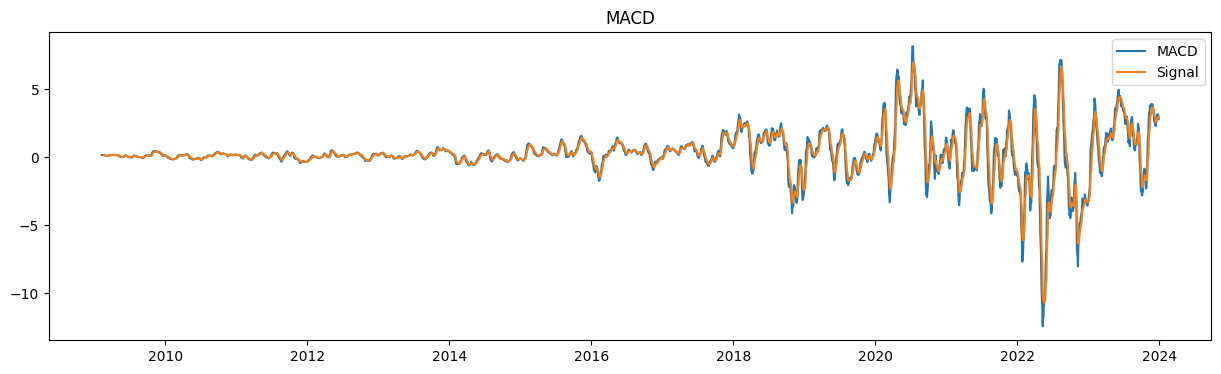

In [10]:
plt.figure(figsize=(15,4))

plt.plot(df['MACD'], label='MACD')

plt.plot(df['MACD_signal'], label='Signal')

plt.legend()

plt.title("MACD")

plt.show()

In [11]:

df['daily_return'] = df['Close'].pct_change()
df['daily_return'].describe()

count    3773.000000
mean        0.001303
std         0.021829
min        -0.140494
25%        -0.009258
50%         0.000916
75%         0.012208
max         0.267951
Name: daily_return, dtype: float64